In [25]:
import scipy
# Read the CSV files
df_blue = pd.read_csv('pass_gen_comparison_blue.csv', header=None)
df_yellow = pd.read_csv('pass_gen_comparison_yellow.csv', header=None)

# Concatenate the dataframes
df_combined = pd.concat([df_blue, df_yellow], axis=0)
df_combined = df_combined.dropna()

scipy.stats.mode(df_combined)

/tmp/ipykernel_18194/1781687529.py:10: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  scipy.stats.mode(df_combined)


ModeResult(mode=array([[0.      , 0.      , 0.756115]]), count=array([[115, 107, 379]]))

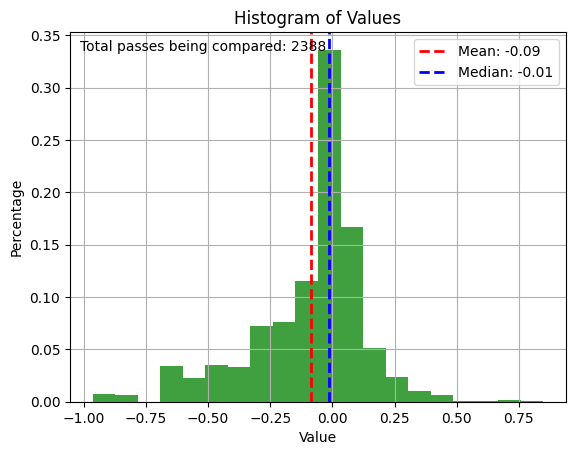

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV files
df_blue = pd.read_csv('pass_gen_comparison_blue.csv', header=None)
df_yellow = pd.read_csv('pass_gen_comparison_yellow.csv', header=None)

# Concatenate the dataframes
df_combined = pd.concat([df_blue, df_yellow], axis=1)
df_combined = df_combined.dropna()

# Calculate weights for each value to represent percentages
weights = np.ones_like(df_combined.values.flatten()) / len(df_combined.values.flatten())

# Calculate mean and median
mean_val = np.mean(df_combined.values.flatten())
median_val = np.median(df_combined.values.flatten())

# Calculate total number of data points
total_data_points = len(df_combined.values.flatten())

# Plot a histogram
plt.hist(df_combined.values.flatten(), bins=20, color='g', alpha=0.75, weights=weights)

# Draw lines for mean and median
plt.axvline(mean_val, color='r', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='b', linestyle='dashed', linewidth=2, label=f'Median: {median_val:.2f}')

# Add text for total number of data points
plt.text(0.02, 0.95, f'Total passes being compared: {total_data_points}', transform=plt.gca().transAxes)

plt.xlabel('Value')
plt.ylabel('Percentage')
plt.title('Histogram of Values')
plt.legend()
plt.grid(True)
plt.show()

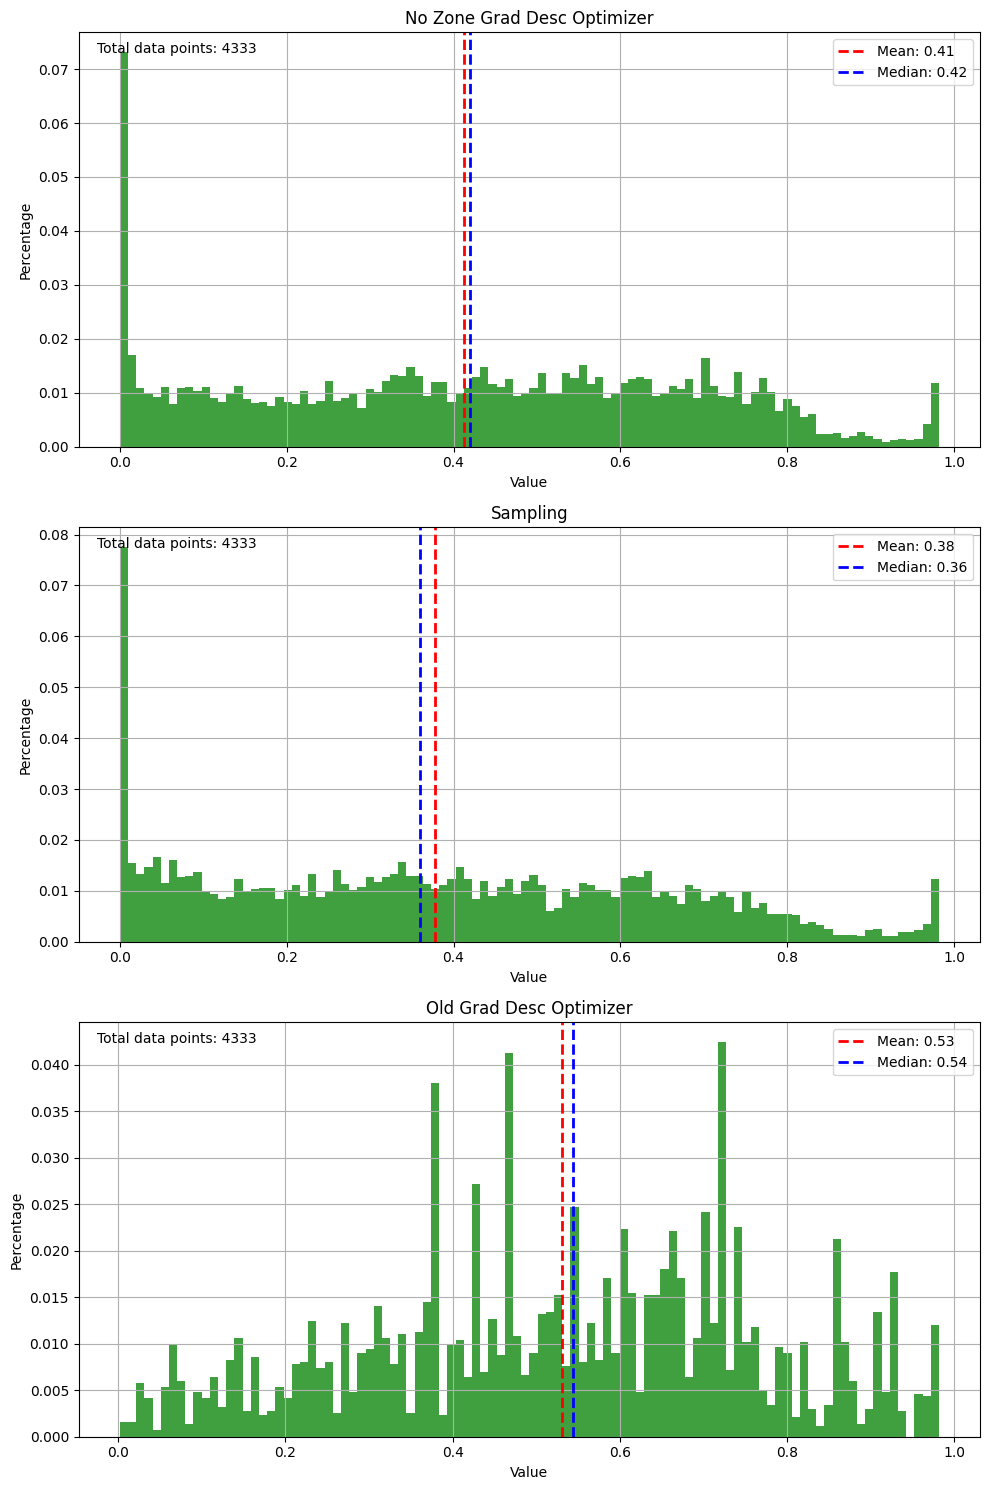

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the CSV files
df_blue = pd.read_csv('pass_gen_comparison_blue.csv', header=None)
df_yellow = pd.read_csv('pass_gen_comparison_yellow.csv', header=None)

# Concatenate the dataframes
df_combined = pd.concat([df_blue, df_yellow], axis=0)
df_combined = df_combined.dropna()

# Create a figure with three subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

titles = ["No Zone Grad Desc Optimizer", "Sampling", "Old Grad Desc Optimizer"]

# Plot a histogram for each column
for i in range(3):
    # Calculate weights for each value to represent percentages
    weights = np.ones_like(df_combined[i].values) / len(df_combined[i].values)

    # Calculate mean and median
    mean_val = np.mean(df_combined[i].values)
    median_val = np.median(df_combined[i].values)

    # Calculate total number of data points
    total_data_points = len(df_combined[i].values)

    # Plot a histogram
    axs[i].hist(df_combined[i].values, bins=100, color='g', alpha=0.75, weights=weights)

    # Draw lines for mean and median
    axs[i].axvline(mean_val, color='r', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
    axs[i].axvline(median_val, color='b', linestyle='dashed', linewidth=2, label=f'Median: {median_val:.2f}')

    # Add text for total number of data points
    axs[i].text(0.02, 0.95, f'Total data points: {total_data_points}', transform=axs[i].transAxes)

    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Percentage')
    axs[i].set_title(titles[i])
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()